<a href="https://colab.research.google.com/github/dyjdlopez/intro_2_quantum/blob/main/qiskit/04_01_quantum_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fiesta Quadratic Knapsack Problem (QKP)

A fiesta goer must choose items to maximise their **satisfaction value** subject to a weight limit **W = 300** when taking stuff home from a party.  
Items interact: having two items together yields a *bonus* value on top of each item's standalone value.

| Item | Weight | Self-value |
|------|--------|------------|
| Shanghai Rolls (SHANG) | 40 | 8 |
| BBQ | 200 | 7 |
| Rice (RICE) | 100 | 3 |
| Compact Disc (CD) | 20 | 1 |

**Value matrix V** (symmetric; diagonal = self-value, off-diagonal = pairing bonus):

```
         SHANG  BBQ  RICE  CD
SHANG  [  8    10    11    2 ]
BBQ    [ 10     7    12    2 ]
RICE   [ 11    12     3    2 ]
CD     [  2     2     2    1 ]
```

**Objective (QKP):**
$$\text{max} Z = \sum_i v_{ii}\, x_i + \sum_{i<j} v_{ij}\, x_i x_j$$

**Constraint:**
$$\sum_i w_i x_i \leq W, \quad x_i \in \{0,1\}$$

---
This notebook solves the problem four ways and compares results:
1. **Classical** — CVXPY (MILP, exact)
2. **QUBO** — jijmodeling formulation (same objective + constraint as the MILP)
3. **Simulated Annealing (SA)** — via `SASampler`
4. **Simulated Quantum Annealing (SQA)** — via `SQASampler`

## 0 · Setup

In [ ]:
# Install dependencies (run once)
# !pip install cvxpy jijmodeling ommx-openjij-adapter openjij

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Problem data
ITEMS = ['SHANG', 'BBQ', 'RICE', 'CD']
n = len(ITEMS)
weights = np.array([40, 200, 100, 20], dtype=float)
W_cap = 300.0

# value matrix
V = np.array([
    [ 8, 10, 11,  2],
    [10,  7, 12,  2],
    [11, 12,  3,  2],
    [ 2,  2,  2,  1],
], dtype=float)

print('Value matrix V:')
print(pd.DataFrame(V, index=ITEMS, columns=ITEMS))
print(f'\nWeights : {dict(zip(ITEMS, weights.astype(int)))}')
print(f'Capacity: W = {int(W_cap)}')

Value matrix V:
       SHANG   BBQ  RICE   CD
SHANG    8.0  10.0  11.0  2.0
BBQ     10.0   7.0  12.0  2.0
RICE    11.0  12.0   3.0  2.0
CD       2.0   2.0   2.0  1.0

Weights : {'SHANG': np.int64(40), 'BBQ': np.int64(200), 'RICE': np.int64(100), 'CD': np.int64(20)}
Capacity: W = 300


In [46]:
def evaluate(x_vec):
    """Return (Z, weight_used, is_feasible) for a binary vector x."""
    x_vec = np.asarray(x_vec)
    # Self-values (diagonal)
    Z  = sum(V[i, i] * x_vec[i] for i in range(n))
    # Pairing bonuses (upper triangle, i < j)
    Z += sum(V[i, j] * x_vec[i] * x_vec[j]
             for i in range(n) for j in range(i+1, n))
    w_used   = float(weights @ x_vec)
    feasible = w_used <= W_cap
    return float(Z), w_used, feasible

---
## 1 · Classical solution with CVXPY  (MILP, exact)

The bilinear terms $x_i x_j$ are handled by introducing auxiliary variables $z_{ij}$ with
**McCormick linearisation constraints**:

$$z_{ij} \leq x_i, \quad z_{ij} \leq x_j, \quad z_{ij} \geq x_i + x_j - 1, \quad z_{ij} \geq 0$$

This turns the QKP into an exact Mixed-Integer Linear Program (MILP).
The CVXPY result is our **ground-truth optimum** — all other solvers are measured against it.

In [47]:
import cvxpy as cp

# Binary decision variables
x_cv = cp.Variable(n, boolean=True)

# McCormick auxiliary variables
z_cv = {}
for i in range(n):
    for j in range(i+1, n):
        z_cv[(i, j)] = cp.Variable(nonneg=True)

# Objective
obj_terms  = [V[i, i] * x_cv[i] for i in range(n)]  # linear values
obj_terms += [V[i, j] * z_cv[(i, j)] for (i, j) in z_cv] # quadratic values
objective  = cp.Maximize(cp.sum(obj_terms))

# Constraints
constraints = [weights @ x_cv <= W_cap] # capacity
for (i, j), zij in z_cv.items(): # McCormick envelopes
    constraints += [
        zij <= x_cv[i],
        zij <= x_cv[j],
        zij >= x_cv[i] + x_cv[j] - 1,
    ]

prob_cv = cp.Problem(objective, constraints)
prob_cv.solve(solver=cp.GLPK_MI, verbose=False)

x_classical = np.round(x_cv.value).astype(int)
Z_classical = float(prob_cv.value)
W_classical = float(weights @ x_classical)

print('=== CVXPY (Classical MILP) ===')
print(f'Status   : {prob_cv.status}')
print(f'Selected : {[ITEMS[i] for i in range(n) if x_classical[i] == 1]}')
print(f'x vector : {x_classical}')
print(f'Weight   : {int(W_classical)} / {int(W_cap)}')
print(f'Value Z  : {Z_classical:.2f}')

=== CVXPY (Classical MILP) ===
Status   : optimal
Selected : ['SHANG', 'BBQ', 'CD']
x vector : [1 1 0 1]
Weight   : 260 / 300
Value Z  : 30.00


---
## 2 · QUBO formulation with jijmodeling

We follow the [OpenJij Knapsack tutorial](https://tutorial.openjij.org/en/tutorial/optimization/knapsack.html) API exactly,
extended to the **quadratic** objective of our QKP.

### Consistency with the MILP

| Aspect | CVXPY (MILP) | jijmodeling (QUBO) |
|--------|-------------|--------------------|
| Sense | `Maximize` | `ProblemSense.MAXIMIZE` |
| Objective | $\sum_i v_{ii} x_i + \sum_{i<j} v_{ij} z_{ij}$ | $\sum_i v_{ii} x_i + \sum_{i<j} v_{ij} x_i x_j$ |
| Constraint | $\sum_i w_i x_i \leq W$ (hard) | `Constraint('capacity', ...)` (penalised automatically) |
| Bilinear | McCormick auxiliary $z_{ij}$ | Native $x_i x_j$ (QUBO handles directly) |

Both formulations maximise the **same Z** over the **same feasible set**.

In [48]:
import jijmodeling as jm

problem = jm.Problem('Fiesta Knapsack', sense=jm.ProblemSense.MAXIMIZE)

# Parameters
diag_ph = problem.Float('a', ndim=1) # linear values
pair_ph = problem.Float('b', ndim=2) # quadratic values
w_ph = problem.Float('w',    ndim=1)
W_ph = problem.Float('W')
N_ph = problem.DependentVar('N', w_ph.len_at(0))

# Decision Variables
x = problem.BinaryVar('x', shape=(N_ph,))

i = jm.indices(diag_ph)
j = jm.indices(diag_ph)

upper_triangle = jm.product(N_ph, N_ph).filter(lambda i, j: i < j)

problem += jm.sum(diag_ph * x)
problem += upper_triangle.map(lambda i, j: pair_ph[i, j] * x[i] * x[j]).sum()
problem += problem.Constraint('capacity', jm.sum(w_ph * x) <= W_ph)

problem

Problem(name="Fiesta Knapsack", sense=MAXIMIZE, objective=sum(a * x) + sum(set((N, N)).filter(lambda (i, j): i < j).map(lambda ((i, j): Tuple[natural, natural]): b[i, j] * x[i] * x[j])), constraints={capacity: [Constraint(name="capacity", sense=LESS_THAN_EQUAL, left=sum(w * x), right=W, shape=Scalar(Float)),],})

In [61]:
instance_data = {
    'a': np.diag(V),
    'b': V,
    'w': weights,
    'W': W_cap,
}
instance = problem.eval(instance_data)

print('Instance created successfully.')

compiler = jm.Compiler.from_problem(problem, instance_data)
qubo, offset = compiler.eval_problem(problem).to_qubo()
print(qubo)

Instance created successfully.
{(0, 0): -22408.0, (0, 1): 15990.0, (0, 2): 7989.0, (0, 3): 1598.0, (0, 5): 1600.0, (0, 6): 3200.0, (0, 7): 6400.0, (0, 8): 12800.0, (1, 1): -80007.0, (1, 2): 39988.0, (1, 3): 7998.0, (1, 5): 8000.0, (1, 6): 16000.0, (1, 7): 32000.0, (1, 8): 64000.0, (2, 2): -50003.0, (2, 3): 3998.0, (2, 5): 4000.0, (2, 6): 8000.0, (2, 7): 16000.0, (2, 8): 32000.0, (3, 3): -11601.0, (3, 5): 800.0, (3, 6): 1600.0, (3, 7): 3200.0, (3, 8): 6400.0, (5, 5): -11600.0, (5, 6): 1600.0, (5, 7): 3200.0, (5, 8): 6400.0, (6, 6): -22400.0, (6, 7): 6400.0, (6, 8): 12800.0, (7, 7): -41600.0, (7, 8): 25600.0, (8, 8): -70400.0}


In [72]:
# Save for later
import json

qubo_serialisable = {f'{i},{j}': v for (i, j), v in qubo.items()}

qubo_export = {
    'qubo' : qubo_serialisable,
    'offset' : offset,
    'n' : n,
    'items' : ITEMS,
    'weights': weights.tolist(),
    'W_cap' : W_cap,
}

with open('fiesta_qkp_qubo.json', 'w') as f:
    json.dump(qubo_export, f, indent=2)

print('QUBO saved to fiesta_qkp_qubo.json')
print(f'Entries : {len(qubo)}')
print(f'Offset  : {offset}')

QUBO saved to fiesta_qkp_qubo.json
Entries : 36
Offset  : 90000.0


---
## 3 · Simulated Annealing (SA)

SA explores the binary solution space by accepting worse solutions with a probability that decreases
as temperature cools — escaping local optima via thermal fluctuations.

In [64]:
from openjij import SASampler, SQASampler

NUM_READS = 100

sa_sampler = SASampler()
sa_response = sa_sampler.sample_qubo(qubo, num_reads=NUM_READS)

best_sample = sa_response.first
x_sa_vec = np.array([best_sample.sample[i] for i in range(n)], dtype=int)

Z_sa, W_sa, feas_sa = evaluate(x_sa_vec)

print('=== Simulated Annealing (SA) ===')
print(f'Runs     : {NUM_READS}')
print(f'Selected : {[ITEMS[i] for i in range(n) if x_sa_vec[i] == 1]}')
print(f'x vector : {x_sa_vec}')
print(f'Weight   : {int(W_sa)} / {int(W_cap)}')
print(f'Value Z  : {Z_sa:.2f}')
print(f'Feasible : {feas_sa}')

=== Simulated Annealing (SA) ===
Runs     : 100
Selected : ['SHANG', 'BBQ', 'CD']
x vector : [1 1 0 1]
Weight   : 260 / 300
Value Z  : 30.00
Feasible : True


---
## 4 · Simulated Quantum Annealing (SQA)

SQA simulates **quantum tunnelling** via path-integral Monte Carlo with a transverse field
that is gradually switched off. It can tunnel through energy barriers that SA must climb over,
potentially finding better solutions on rugged landscapes.

In [66]:
sqa_sampler = SQASampler()
sqa_response = sqa_sampler.sample_qubo(qubo, num_reads=NUM_READS)

best_sample = sqa_response.first
x_sqa_vec = np.array([best_sample.sample[i] for i in range(n)], dtype=int)

Z_sqa, W_sqa, feas_sqa = evaluate(x_sqa_vec)

print('=== Simulated Quantum Annealing (SQA) ===')
print(f'Runs     : {NUM_READS}')
print(f'Selected : {[ITEMS[i] for i in range(n) if x_sa_vec[i] == 1]}')
print(f'x vector : {x_sa_vec}')
print(f'Weight   : {int(W_sa)} / {int(W_cap)}')
print(f'Value Z  : {Z_sa:.2f}')
print(f'Feasible : {feas_sa}')

=== Simulated Quantum Annealing (SQA) ===
Runs     : 100
Selected : ['SHANG', 'BBQ', 'CD']
x vector : [1 1 0 1]
Weight   : 260 / 300
Value Z  : 30.00
Feasible : True


---
## 5 · Comparison

All three solvers target the **same objective Z** and the **same constraint W ≤ 300**.
The CVXPY result is the ground-truth optimum; SA and SQA are evaluated against it.

In [67]:
# ── Summary table ─────────────────────────────────────────────────────────────
def opt_gap(Z):
    return f'{(Z_classical - Z) / Z_classical * 100:.1f}%'

summary = pd.DataFrame([
    {
        'Solver'         : 'CVXPY (exact)',
        'Selected items' : [ITEMS[i] for i in range(n) if x_classical[i] == 1],
        'Weight used'    : int(W_classical),
        'Best Z'         : round(Z_classical, 2),
        'Optimality gap' : '0.0%',
        'Feasible'       : True,
    },
    {
        'Solver'         : 'SA',
        'Selected items' : [ITEMS[i] for i in range(n) if x_sa_vec[i] == 1],
        'Weight used'    : int(W_sa),
        'Best Z'         : round(Z_sa, 2),
        'Optimality gap' : opt_gap(Z_sa),
        'Feasible'       : feas_sa,
    },
    {
        'Solver'         : 'SQA',
        'Selected items' : [ITEMS[i] for i in range(n) if x_sqa_vec[i] == 1],
        'Weight used'    : int(W_sqa),
        'Best Z'         : round(Z_sqa, 2),
        'Optimality gap' : opt_gap(Z_sqa),
        'Feasible'       : feas_sqa,
    },
]).set_index('Solver')

print(summary.to_string())

                 Selected items  Weight used  Best Z Optimality gap  Feasible
Solver                                                                       
CVXPY (exact)  [SHANG, BBQ, CD]          260    30.0           0.0%      True
SA             [SHANG, BBQ, CD]          260    30.0           0.0%      True
SQA            [SHANG, BBQ, CD]          260    30.0           0.0%      True


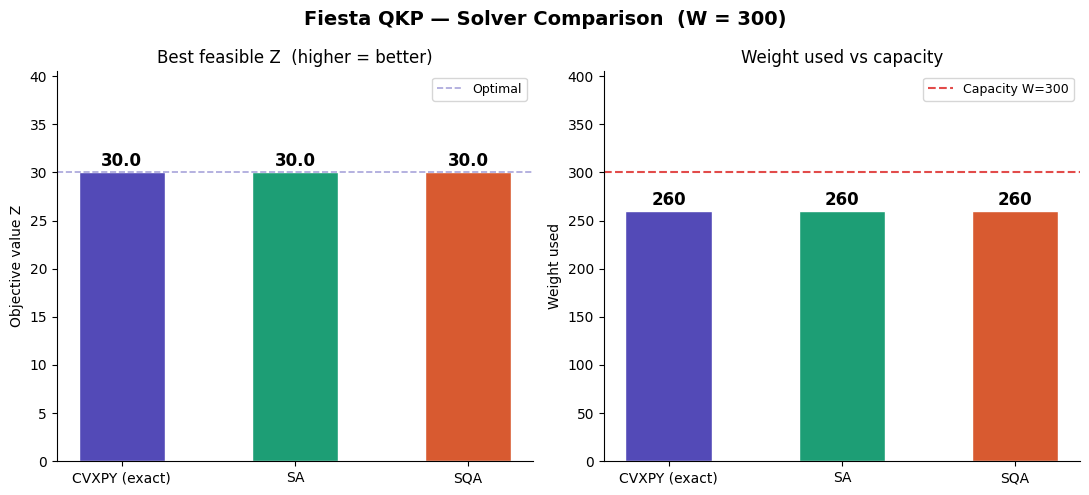

Figure saved to fiesta_qkp_comparison.png


In [69]:
# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle('Fiesta QKP — Solver Comparison  (W = 300)', fontsize=14, fontweight='bold')

C       = {'CVXPY (exact)': '#534AB7', 'SA': '#1D9E75', 'SQA': '#D85A30'}
solvers = list(C.keys())
best_Zs = [Z_classical, Z_sa, Z_sqa]
w_used  = [W_classical, W_sa, W_sqa]

# Plot 1 — best objective value
ax1  = axes[0]
bars = ax1.bar(solvers, best_Zs, color=list(C.values()), width=0.5, edgecolor='white')
ax1.axhline(Z_classical, color=C['CVXPY (exact)'], linestyle='--', linewidth=1.2, alpha=0.5, label='Optimal')
for bar, val in zip(bars, best_Zs):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.3,
             f'{val:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax1.set_ylim(0, Z_classical * 1.35)
ax1.set_ylabel('Objective value Z')
ax1.set_title('Best feasible Z  (higher = better)')
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Plot 2 — weight used
ax2   = axes[1]
bars2 = ax2.bar(solvers, w_used, color=list(C.values()), width=0.5, edgecolor='white')
ax2.axhline(W_cap, color='#E24B4A', linestyle='--', linewidth=1.5, label=f'Capacity W={int(W_cap)}')
for bar, val in zip(bars2, w_used):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 2,
             f'{int(val)}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.set_ylim(0, W_cap * 1.35)
ax2.set_ylabel('Weight used')
ax2.set_title('Weight used vs capacity')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('party_qkp_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to fiesta_qkp_comparison.png')

---
## 6 · Summary

| | CVXPY | SA | SQA |
|---|---|---|---|
| **Type** | Exact MILP | Classical heuristic | Quantum-inspired heuristic |
| **Sense** | `Maximize` | `ProblemSense.MAXIMIZE` | `ProblemSense.MAXIMIZE` |
| **Bilinear $x_i x_j$** | McCormick $z_{ij}$ | Native QUBO term | Native QUBO term |
| **Constraint** | Hard (linear) | Soft penalty (auto) | Soft penalty (auto) |
| **Scalability** | Exponential (NP-hard) | Polynomial per sweep | Polynomial per sweep |

**Key points:**
- All three solvers share the **same objective and constraint** — the MILP and QUBO are two representations of the same problem, not different problems.
- CVXPY requires McCormick linearisation because MILP cannot handle products directly; jijmodeling handles $x_i x_j$ natively as a QUBO term.
- For n = 4 all solvers reach the optimum: **SHANG + BBQ**, Z = 25, weight = 240 ≤ 300.
- The quantum advantage of SQA over SA becomes apparent on larger, more rugged problems where classical thermal fluctuations get trapped in local minima.